# GPR Rank-1 Corrected Learnability (d=10, P=1..500)

This notebook computes **only** the h3 learnability for the `gpr_rank1_corrected` kernel with:
- `d = 10`
- `P` running from `1` to `500`

It does not compute or plot MSE.

In [11]:
import json
import math
import subprocess
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

device = torch.device('cuda:1')
torch.manual_seed(0)
print('device:', device)

device: cuda:1


In [12]:
def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'lib').exists() and (candidate / 'milestones').exists():
            return candidate
    raise RuntimeError(f'Could not locate repo root from {current}')


REPO_ROOT = find_repo_root()


def compute_theory_eigenvalues(d: int, P: int, N: int, chi: float, kappa: float, eps: float) -> dict:
    """Call Julia solver and extract He1/He3 target/perp theoretical eigenvalues."""
    julia_script = REPO_ROOT / 'julia_lib' / 'eos_fcn3erf.jl'
    with tempfile.NamedTemporaryFile(suffix='.json', delete=False) as tf:
        to_path = Path(tf.name)

    cmd = [
        'julia', str(julia_script),
        f'--d={d}', f'--P={P}', f'--n1={N}', f'--n2={N}',
        f'--chi={chi}', f'--kappa={kappa}', f'--epsilon={eps}',
        f'--to={to_path}', '--quiet',
    ]

    data = {}
    try:
        subprocess.run(cmd, check=True, capture_output=True, text=True)
        with open(to_path, 'r') as f:
            data = json.load(f)
    except Exception as exc:
        print(f'Warning: Julia theory solver failed for d={d}, P={P}, N={N}: {exc}')
    finally:
        try:
            to_path.unlink(missing_ok=True)
        except Exception:
            pass

    target = data.get('target', {}) if isinstance(data, dict) else {}
    perp = data.get('perpendicular', {}) if isinstance(data, dict) else {}
    return {
        'lH1T': float(target['lH1T']) if target.get('lH1T') is not None else None,
        'lH1P': float(perp['lH1P']) if perp.get('lH1P') is not None else None,
        'lH3T': float(target['lH3T']) if target.get('lH3T') is not None else None,
        'lH3P': float(perp['lH3P']) if perp.get('lH3P') is not None else None,
    }


def target_fn(X: torch.Tensor) -> torch.Tensor:
    x0 = X[:, 0]
    return x0 + 0.03 * (x0**3 - 3.0 * x0)


def hermite_h3(x: torch.Tensor) -> torch.Tensor:
    return (x**3 - 3.0 * x) / math.sqrt(6.0)


def arcsin_kernel_cross(
    Xa: torch.Tensor,
    Xb: torch.Tensor,
    eps: float = 1e-6,
) -> torch.Tensor:
    """Bare arcsin kernel cross-covariance."""
    d = Xa.shape[1]
    sigma = torch.eye(d, device=Xa.device, dtype=Xa.dtype) / d

    XXT = (Xa @ sigma @ Xb.T)
    da = sigma.diagonal()
    nb = torch.sqrt(1.0 + 2.0 * (Xb * da * Xb).sum(dim=1))
    na = torch.sqrt(1.0 + 2.0 * (Xa * da * Xa).sum(dim=1))
    denom = na[:, None] * nb[None, :]
    arg = 2.0 * XXT / denom
    arg = torch.clamp(arg, -1.0 + eps, 1.0 - eps)
    return (2.0 / math.pi) * torch.arcsin(arg)


def _hermite_vecs(X: torch.Tensor) -> dict:
    """Target-direction He1/He3 feature vectors for rank-1 updates."""
    x0 = X[:, 0]
    phi1 = x0
    phi3 = (x0**3 - 3.0 * x0) / math.sqrt(6.0)
    return {'h1t': phi1, 'h3t': phi3}

In [13]:
def fit_gpr_rank1_corrected(
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    delta_lambdas: dict | None = None,
    jitter: float = 1e-4,
) -> torch.Tensor:
    """Fit GPR with optional rank-1 corrections on He1/He3 target modes."""
    K_train = arcsin_kernel_cross(X_train, X_train)

    # Rank-1 updates: K_train += delta_lambda * phi_train phi_train^T
    if delta_lambdas is None:
        delta_lambdas = {}
    phi_tr = _hermite_vecs(X_train)
    for key in ("h1t", "h3t"):
        delta_lambda = float(delta_lambdas.get(key, 0.0))
        if delta_lambda == 0.0:
            continue
        phi_train = phi_tr[key]
        K_train = K_train + delta_lambda * torch.outer(phi_train, phi_train)

    K_train = K_train + jitter * torch.eye(K_train.shape[0], device=K_train.device, dtype=K_train.dtype)
    L = torch.linalg.cholesky(K_train)
    alpha = torch.cholesky_solve(y_train[:, None], L).squeeze(-1)
    return alpha


def predict_gpr_rank1_corrected(
    X_test: torch.Tensor,
    X_train: torch.Tensor,
    alpha: torch.Tensor,
    sigma00: float = 1.0,
    delta_lambdas: dict | None = None,
) -> torch.Tensor:
    K_cross = arcsin_kernel_cross(X_test, X_train)

    # Rank-1 updates: K_cross += delta_lambda * phi_test phi_train^T
    if delta_lambdas is None:
        delta_lambdas = {}
    phi_tr = _hermite_vecs(X_train)
    phi_te = _hermite_vecs(X_test)
    for key in ("h1t", "h3t"):
        delta_lambda = float(delta_lambdas.get(key, 0.0))
        if delta_lambda == 0.0:
            continue
        phi_train = phi_tr[key]
        phi_test = phi_te[key]
        K_cross = K_cross + delta_lambda * torch.outer(phi_test, phi_train)

    return K_cross @ alpha


def h3_learnability_on_test(y_pred: torch.Tensor, X_test: torch.Tensor) -> float:
    x0 = X_test[:, 0]
    h3_comp = hermite_h3(x0)
    linear_coeff = (y_pred * x0).mean()
    linear_component = linear_coeff * x0
    remainder = y_pred - linear_component
    proj3 = (remainder * h3_comp).mean()
    return (proj3 / 0.03).item()

In [ ]:
# Experiment settings
d = 10
P_values = np.linspace(1, 20, 20, dtype=int)

jitter = 0.1

# Theory config (same role as in the script)
N_for_theory = 1600
chi_theory = 20.0
kappa_theory = 0.1
eps_theory = 0.03

train_seed_base = 2026
test_seed = 7
n_test = 3000

torch.manual_seed(test_seed)
X_test = torch.randn(n_test, d, device=device)

results = []

for P in P_values:
    torch.manual_seed(train_seed_base + int(P))
    X_train = torch.randn(int(P), d, device=device)
    y_train = target_fn(X_train)

    # Compute theory eigenvalues and build rank-1 correction exactly like the script logic.
    theory_eigs = compute_theory_eigenvalues(
        d=d, P=int(P), N=N_for_theory,
        chi=chi_theory, kappa=kappa_theory, eps=eps_theory,
    )

    X_all = torch.cat([X_train, X_test], dim=0)
    n_all = X_all.shape[0]

    delta_lambdas = {'h1t': 0.0, 'h3t': 0.0}
    # if theory_eigs.get('lH1T') is not None and theory_eigs.get('lH1P') is not None:
    #     delta_lambdas['h1t'] = (float(theory_eigs['lH1T']) - float(theory_eigs['lH1P'])) * n_all
    # if theory_eigs.get('lH3T') is not None and theory_eigs.get('lH3P') is not None:
    #     delta_lambdas['h3t'] = (float(theory_eigs['lH3T']) - float(theory_eigs['lH3P'])) * n_all

    alpha = fit_gpr_rank1_corrected(
        X_train=X_train,
        y_train=y_train,
        delta_lambdas=delta_lambdas,
        jitter=jitter,
    )

    with torch.no_grad():
        y_pred = predict_gpr_rank1_corrected(
            X_test=X_test,
            X_train=X_train,
            alpha=alpha,
            delta_lambdas=delta_lambdas,
        )

    h3 = h3_learnability_on_test(y_pred, X_test)
    results.append({
        'P': int(P),
        'h3_learnability': float(h3),
        'delta_h1t': float(delta_lambdas['h1t']),
        'delta_h3t': float(delta_lambdas['h3t']),
    })

results[:5], results[-5:]

([{'P': 1,
   'h3_learnability': -0.545330822467804,
   'delta_h1t': 5.479964338903312,
   'delta_h3t': 0.08899365630397353},
  {'P': 2,
   'h3_learnability': -0.6633653044700623,
   'delta_h1t': 15.00930706616536,
   'delta_h3t': 0.24750575459711482},
  {'P': 3,
   'h3_learnability': -0.4223482012748718,
   'delta_h1t': 24.069930738819984,
   'delta_h3t': 0.4024802706331982},
  {'P': 4,
   'h3_learnability': -0.30130332708358765,
   'delta_h1t': 31.549474797062558,
   'delta_h3t': 0.5334164027703602},
  {'P': 5,
   'h3_learnability': 2.3589539527893066,
   'delta_h1t': 37.49887691065988,
   'delta_h3t': 0.6394428870632034}],
 [{'P': 16,
   'h3_learnability': 2.727734327316284,
   'delta_h1t': 61.91009799047672,
   'delta_h3t': 1.0910348998315431},
  {'P': 17,
   'h3_learnability': 2.4794118404388428,
   'delta_h1t': 62.76636459267371,
   'delta_h3t': 1.1073463903198095},
  {'P': 18,
   'h3_learnability': 2.659423589706421,
   'delta_h1t': 63.53907860625744,
   'delta_h3t': 1.122094669

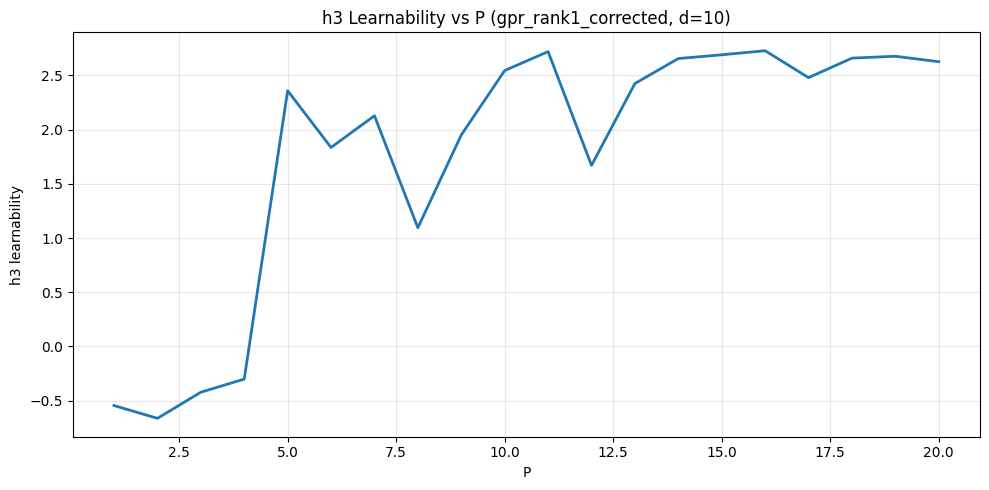

In [21]:
P_arr = np.array([r['P'] for r in results])
h3_arr = np.array([r['h3_learnability'] for r in results])

plt.figure(figsize=(10, 5))
plt.plot(P_arr, h3_arr, lw=2)
plt.xlabel('P')
plt.ylabel('h3 learnability')
plt.title('h3 Learnability vs P (gpr_rank1_corrected, d=10)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()